In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x22DFF2DA750>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class Net(nn.Module):
    def __init__(self, sigma1=0, sigma2=0, sigma3=0, relative=True):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256),
            nn.ReLU(),
            GaussianActivationNoise(sigma3, relative),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

# Шум параметров

In [13]:
def get_omega_for_parameter(name, omega1, omega2, omega3):
    if name.startswith('block1'):
        return omega1
    elif name.startswith('block2'):
        return omega2
    else:
        return omega3

# Атаки

In [14]:
def fgsm_attack(model, inputs, labels, criterion, epsilon):
    model.eval()
    inputs.requires_grad = True
    outputs = model(inputs)
    loss = criterion(outputs, labels)

    model.zero_grad()
    loss.backward()

    data_grad = inputs.grad.data
    adversarial_inputs = inputs + epsilon * data_grad.sign()

    adversarial_inputs = torch.clamp(adversarial_inputs, 0, 1)

    return adversarial_inputs

In [15]:
def pgd_attack(model, inputs, labels, criterion, epsilon, alpha=0.01, num_iter=10):
    adversarial_inputs = inputs.clone().detach().to(device)
    adversarial_inputs.requires_grad = True

    for i in range(num_iter):
        outputs = model(adversarial_inputs)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()
        with torch.no_grad():
            adversarial_inputs = adversarial_inputs + alpha * adversarial_inputs.grad.sign()
            perturbation = torch.clamp(adversarial_inputs - inputs, min=-epsilon, max=epsilon)
            adversarial_inputs = torch.clamp(inputs + perturbation, min=0, max=1)
        adversarial_inputs.requires_grad = True

    return adversarial_inputs

In [16]:
def test_with_attack(model, test_loader, criterion, attack, epsilon):
    correct = 0
    total = 0

    for data in test_loader:
        inputs, labels = data[0].to(device), data[1].to(device)

        adversarial_inputs = attack(model, inputs, labels, criterion, epsilon)

        outputs = model(adversarial_inputs)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = correct / total
    return accuracy

# Обучение

In [17]:
num_epochs = 20
lr = 1e-2

In [18]:
criterion = nn.CrossEntropyLoss()

In [19]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [20]:
def train(net, num_epochs, omega1, omega2, omega3, relative_params=True):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for name, param in net.named_parameters():
                    if param.requires_grad:
                        omega = get_omega_for_parameter(name, omega1, omega2, omega3)
                        if omega > 0:
                            noise = torch.randn_like(param)

                            if relative_params:
                                scale = param.detach().std()
                                param.add_(omega * scale * noise)
                            else:
                                param.add_(omega * noise)
                
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.5086867653705796, val_acc: 0.5870999693870544, val_loss: 1.2076450729671913
epoch: 2, train loss: 1.0343385256030815, val_acc: 0.7067999839782715, val_loss: 0.8184528290470944
epoch: 3, train loss: 0.857042787399951, val_acc: 0.7355999946594238, val_loss: 0.7481525231011307
epoch: 4, train loss: 0.7687168308960957, val_acc: 0.7529999613761902, val_loss: 0.7077612488330165
epoch: 5, train loss: 0.7048848246486997, val_acc: 0.7746999859809875, val_loss: 0.6524323217476471
epoch: 6, train loss: 0.6638849073793365, val_acc: 0.7798999547958374, val_loss: 0.6404250573508347
epoch: 7, train loss: 0.6237945399430037, val_acc: 0.7786999940872192, val_loss: 0.6565092934083335
epoch: 8, train loss: 0.5941832158154429, val_acc: 0.7870999574661255, val_loss: 0.6348760818378835
epoch: 9, train loss: 0.5671317590518556, val_acc: 0.8112999796867371, val_loss: 0.5622296223912058
epoch: 10, train loss: 0.546045042407566, val_acc: 0.8161999583244324, val_loss: 0.542359759158726
ep

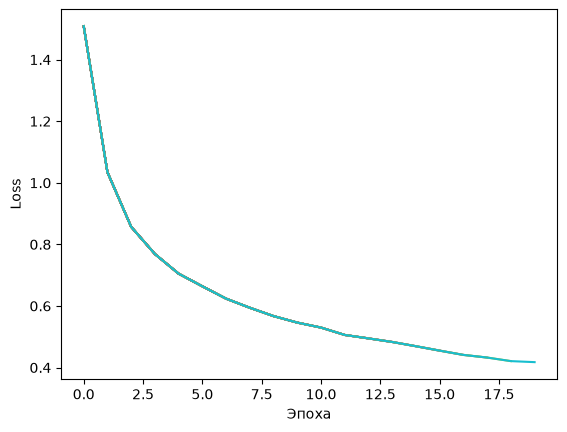

In [21]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [22]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1902

In [23]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0055

epoch: 1, train loss: 1.5226629011461694, val_acc: 0.5625999569892883, val_loss: 1.178652580780319
epoch: 2, train loss: 1.0365858831927324, val_acc: 0.7012999653816223, val_loss: 0.8437937000129796
epoch: 3, train loss: 0.8595570742855145, val_acc: 0.7378000020980835, val_loss: 0.7561460242995733
epoch: 4, train loss: 0.7665206388792623, val_acc: 0.755299985408783, val_loss: 0.7317090200472481
epoch: 5, train loss: 0.7123246877260568, val_acc: 0.7805999517440796, val_loss: 0.6300060960310924
epoch: 6, train loss: 0.6626338848340076, val_acc: 0.7922999858856201, val_loss: 0.6044452944888344
epoch: 7, train loss: 0.6261667485372119, val_acc: 0.7978999614715576, val_loss: 0.5982479456859299
epoch: 8, train loss: 0.5921844856972047, val_acc: 0.786300003528595, val_loss: 0.6392692693426639
epoch: 9, train loss: 0.5657929391889182, val_acc: 0.8157999515533447, val_loss: 0.5419537315640268
epoch: 10, train loss: 0.5408402065235838, val_acc: 0.8222999572753906, val_loss: 0.5221712925011599
ep

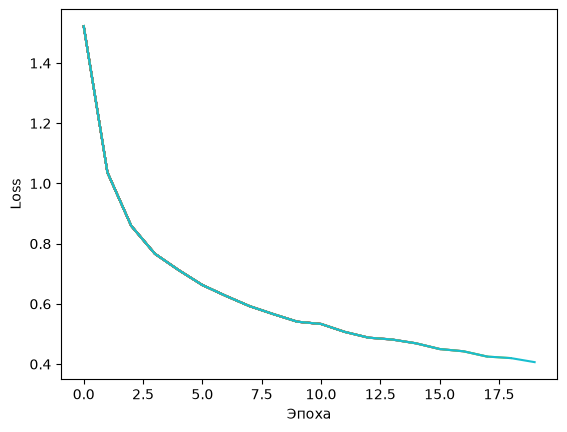

In [24]:
start = time.time()

net = Net(0, 0, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

In [25]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1866

In [26]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0096

epoch: 1, train loss: 1.5295608222141375, val_acc: 0.5830000042915344, val_loss: 1.1442225899877427
epoch: 2, train loss: 1.0867325378890536, val_acc: 0.6603999733924866, val_loss: 0.9663997926289523
epoch: 3, train loss: 0.8873462161229195, val_acc: 0.7152999639511108, val_loss: 0.8208445446400703
epoch: 4, train loss: 0.784320698780504, val_acc: 0.7603999972343445, val_loss: 0.6962064040612571
epoch: 5, train loss: 0.7126228598948099, val_acc: 0.7559999823570251, val_loss: 0.7019879180419294
epoch: 6, train loss: 0.6692340223837265, val_acc: 0.7805999517440796, val_loss: 0.6463453630103341
epoch: 7, train loss: 0.6356477830380258, val_acc: 0.7937999963760376, val_loss: 0.6004394802111613
epoch: 8, train loss: 0.6051638881537065, val_acc: 0.7757999897003174, val_loss: 0.6522125205661677
epoch: 9, train loss: 0.5780217989335362, val_acc: 0.8112999796867371, val_loss: 0.5377126849150355
epoch: 10, train loss: 0.5556720480160765, val_acc: 0.8016999959945679, val_loss: 0.5837804637377775


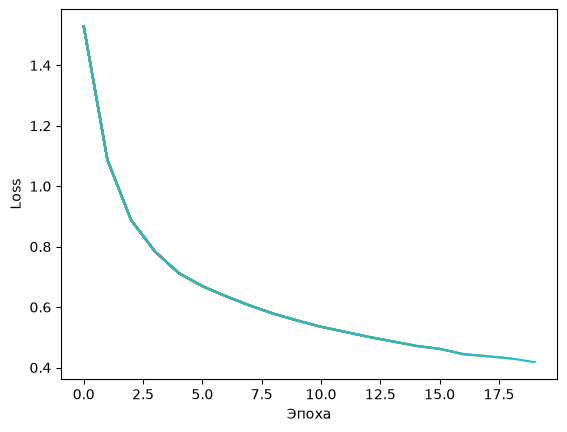

In [27]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

In [28]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1854

In [29]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0074

epoch: 1, train loss: 1.5333321568909473, val_acc: 0.6114999651908875, val_loss: 1.0843159043336217
epoch: 2, train loss: 1.0551392380732112, val_acc: 0.7096999883651733, val_loss: 0.8390041567102263
epoch: 3, train loss: 0.8704901693230322, val_acc: 0.7389000058174133, val_loss: 0.7527195339715933
epoch: 4, train loss: 0.783896801625012, val_acc: 0.7497999668121338, val_loss: 0.7181892832623252
epoch: 5, train loss: 0.7224252492437283, val_acc: 0.75409996509552, val_loss: 0.7007517143140866
epoch: 6, train loss: 0.6805978662889124, val_acc: 0.7766000032424927, val_loss: 0.6645760924755773
epoch: 7, train loss: 0.6411199194074668, val_acc: 0.7859999537467957, val_loss: 0.6376486918594264
epoch: 8, train loss: 0.6102979682953176, val_acc: 0.7936999797821045, val_loss: 0.6066792048985445
epoch: 9, train loss: 0.5867828816623545, val_acc: 0.8026999831199646, val_loss: 0.5892142272448238
epoch: 10, train loss: 0.5572656370932981, val_acc: 0.8061999678611755, val_loss: 0.5738880155207235
ep

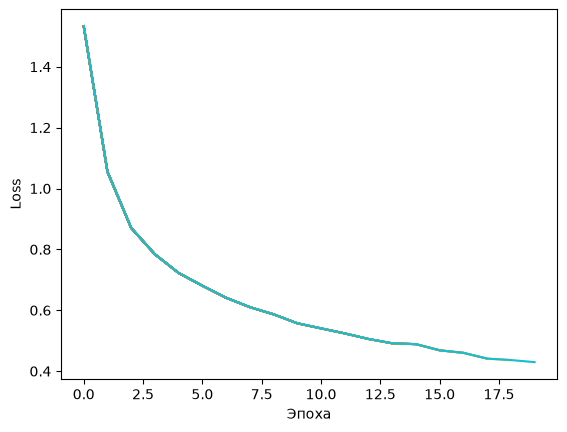

In [30]:
start = time.time()

net = Net(0.03, 0.03, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 1e-4, 1e-4, 1e-4)

print('Время обучения', time.time() - start)

In [31]:
test_with_attack(net, cifar10_loader_test, criterion, fgsm_attack, 8/255)

0.1905

In [32]:
test_with_attack(net, cifar10_loader_test, criterion, pgd_attack, 8/255)

0.0092